In [43]:
import matplotlib.pyplot as plt
import pandas as pd

# Charger toutes les combinaisons
all_combos = pd.read_csv('all_combinations_pipeline.csv')


In [45]:


# ML tank level:
tank_list = ['INTAKE LINE PRESSURE OF HMMF FEED PUMPS', 'FIT_001A_FLOW AT INLET HMMF-A', 'FIT_001B_FLOW AT INLET HMMF-B', 
             'FIT_001C_FLOW AT INLET HMMF-C', 'FIT_001D_FLOW AT INLET HMMF-D', 'FIT_001E_FLOW AT INLET HMMF-E', 'FIT_001F_FLOW AT INLET HMMF-F', 
             'FIT_001G_FLOW AT INLET HMMF-G', 'FIT_001H_FLOW AT INLET HMMF-H', 'FIT_001I_FLOW AT INLET HMMF-I', 'FIT_001J_FLOW AT INLET HMMF-J',
             'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B', 'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 
             'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D', 'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F',
             'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H', 'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I',
             'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J', 'PIT_001 DISCHARGE PRESSURE AT HMMF A-E', 'PIT_001 DISCHARGE PRESSURE AT HMMF F-J']

# ML prod finale:

features_list = [
    'Niveau_reservoir', 'DECISION_BACKWASH_NUM', 'DP_moyen_filtres', 'type_backwash',
    'duree_backwash', 'intervalle_min', 'freq_backwash', 'INDICE_ENCRASSEMENT_HMMF',
    'DEBIT_ENTREE_HMMF', 'INDICE_IMPACT_PRODUCTION', 'INDICE_DESEQUILIBRE_FILTRES',
    'PDIT_001A_DIFF PRESSURE ACROSS HMMF-A', 'PDIT_001B_DIFF PRESSURE ACROSS HMMF-B',
    'PDIT_001C_DIFF PRESSURE ACROSS HMMF-C', 'PDIT_001D_DIFF PRESSURE ACROSS HMMF-D',
    'PDIT_001E_DIFF PRESSURE ACROSS HMMF-E', 'PDIT_001F_DIFF PRESSURE ACROSS HMMF-F',
    'PDIT_001G_DIFF PRESSURE ACROSS HMMF-G', 'PDIT_001H_DIFF PRESSURE ACROSS HMMF-H',
    'PDIT_001I_DIFF PRESSURE ACROSS HMMF-I', 'PDIT_001J_DIFF PRESSURE ACROSS HMMF-J',
    'HMMF-A', 'HMMF-B', 'HMMF-C', 'HMMF-D', 'HMMF-E', 'HMMF-F', 'HMMF-G', 'HMMF-H',
    'HMMF-I', 'HMMF-J'
]


In [47]:
all_combos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4096 entries, 0 to 4095
Data columns (total 46 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Niveau_reservoir                         4096 non-null   float64
 1   hmmf_inlet_flow                          4096 non-null   float64
 2   ro_permeate_flow                         4096 non-null   float64
 3   hmmf_diff_pressure                       4096 non-null   float64
 4   DECISION_BACKWASH_NUM                    4096 non-null   int64  
 5   duree_backwash                           4096 non-null   float64
 6   intervalle_min                           4096 non-null   float64
 7   freq_backwash                            4096 non-null   float64
 8   INDICE_ENCRASSEMENT_HMMF                 4096 non-null   float64
 9   DEBIT_ENTREE_HMMF                        4096 non-null   float64
 10  INDICE_IMPACT_PRODUCTION                 4096 no

In [50]:


import pandas as pd
import joblib

# Fonction générique de prédiction
def predict_tank_and_prod(data_input, tank_list, features_list, tank_col_in_features='Niveau_reservoir'):
    import joblib
    import pandas as pd

    # Charger les modèles et scalers
    tank_model = joblib.load('best_models/ML tank level/best_model_tuned.pkl')
    tank_scaler = joblib.load('best_models/ML tank level/scaler_tuned.pkl')
    prod_model = joblib.load('best_models/ML prod finale/model_Ridge_final.pkl')
    prod_scaler = joblib.load('best_models/ML prod finale/scaler_final.pkl')
    imputer = joblib.load('best_models/ML prod finale/imputer_final.pkl')
    
    # 1️⃣ Prédiction du tank
    data_tank = {col: data_input[col] for col in tank_list}
    X_tank = pd.DataFrame([data_tank])  # <- envelopper dans une liste
    X_tank_scaled = tank_scaler.transform(X_tank)
    tank_pred = tank_model.predict(X_tank_scaled)[0]
    
    # 2️⃣ Injection dans le modèle final
    data_input[tank_col_in_features] = tank_pred  # scalaire
    X_prod = pd.DataFrame([data_input])          # <- envelopper dans une liste
    X_prod = X_prod.reindex(columns=features_list)
    
    # 3️⃣ Imputation, standardisation et prédiction finale
    X_imputed = imputer.transform(X_prod)
    X_scaled = prod_scaler.transform(X_imputed)
    final_pred = prod_model.predict(X_scaled)[0]
    
    return tank_pred, final_pred

'''

# Stocker les résultats
results = []

for idx, row in all_combos.iterrows():
    row_dict = row.to_dict()
    try:
        tank_val, prod_val = predict_tank_and_prod(row_dict, tank_list, features_list)
        results.append({
            **row_dict,
            'Predicted_Tank': tank_val,
            'Predicted_Production': prod_val
        })
    except Exception as e:
        print(f"Erreur à l'index {idx}: {e}")

# Créer DataFrame avec les résultats
results_df = pd.DataFrame(results)

# Sauvegarder les résultats
results_df.to_csv('predicted_production_combinations.csv', index=False)
print("Résultats sauvegardés dans predicted_production_combinations.csv")
'''

# Prendre seulement 10% du dataset
subset_combos = all_combos.sample(frac=0.1, random_state=42)  # random_state pour reproductibilité

results = []

for idx, row in subset_combos.iterrows():
    row_dict = row.to_dict()
    try:
        tank_val, prod_val = predict_tank_and_prod(row_dict, tank_list, features_list)
        results.append({
            **row_dict,
            'Predicted_Tank': tank_val,
            'Predicted_Production': prod_val
        })
    except Exception as e:
        print(f"Erreur à l'index {idx}: {e}")

results_df = pd.DataFrame(results)
results_df.to_csv('predicted_production_combinations_sample.csv', index=False)
print("Résultats sauvegardés dans predicted_production_combinations_sample.csv")


# --- Visualisation ---


C:\Users\yass3\anaconda3\envs\IDSI\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator KNeighborsRegressor from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\yass3\anaconda3\envs\IDSI\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.2.2 when using version 1.7.2. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\yass3\anaconda3\envs\IDSI\Lib\site-packages\sklearn\base.py:442: InconsistentVersionWarning: Trying to unpickle estimator Ridge from version 1.6.1 when using version 1.7.2. T

Résultats sauvegardés dans predicted_production_combinations_sample.csv


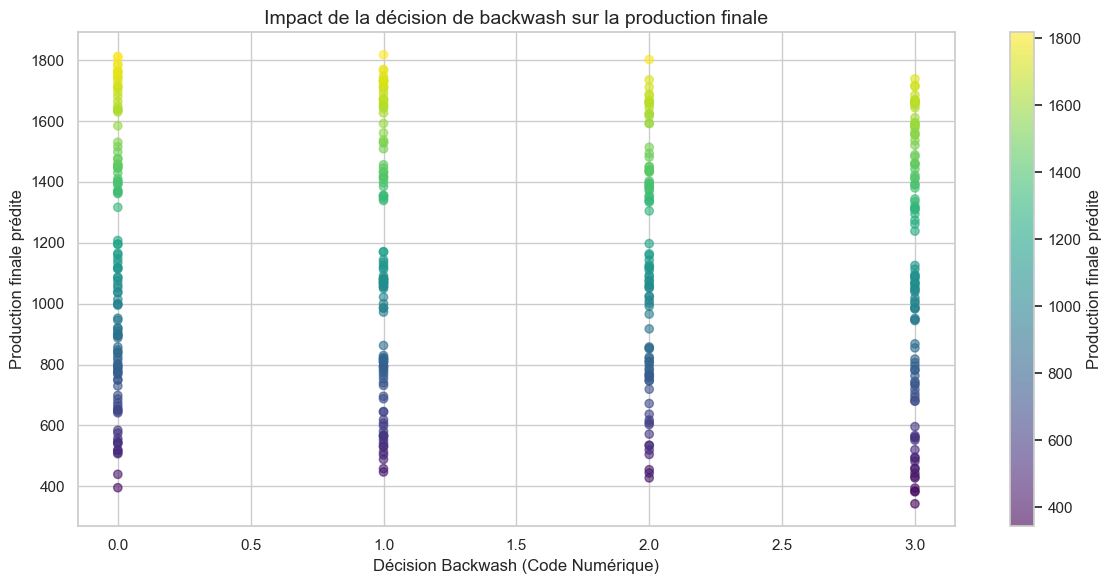

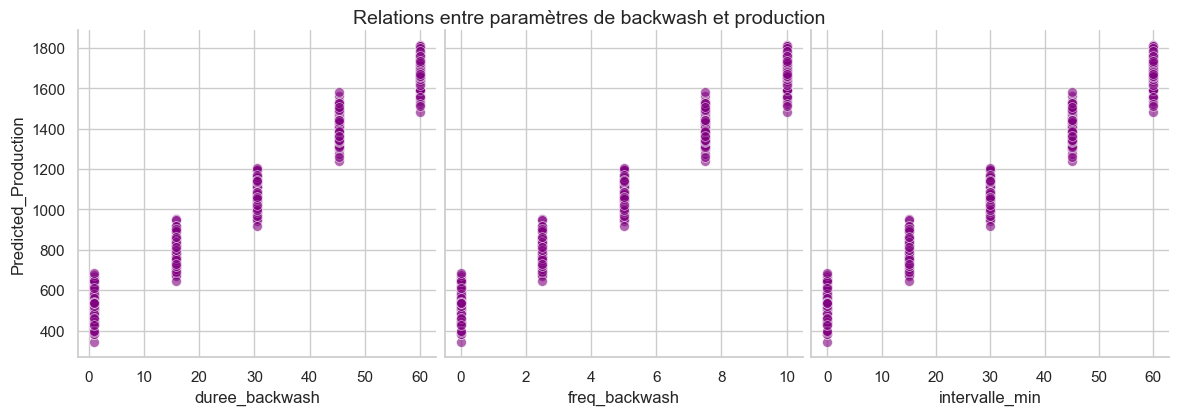

Top 20 combinaisons selon production finale prédite :


,DECISION_BACKWASH_NUM,duree_backwash,freq_backwash,intervalle_min,Predicted_Production
49,1.0,60.0,10.0,60.0,1817.845573
50,0.0,60.0,10.0,60.0,1812.180112
83,0.0,60.0,10.0,60.0,1810.443788
220,2.0,60.0,10.0,60.0,1802.076760
348,0.0,60.0,10.0,60.0,1787.920042
34,0.0,60.0,10.0,60.0,1782.634667
130,1.0,60.0,10.0,60.0,1769.737647
199,1.0,60.0,10.0,60.0,1766.319491
110,0.0,60.0,10.0,60.0,1764.700972
38,0.0,60.0,10.0,60.0,1763.694293


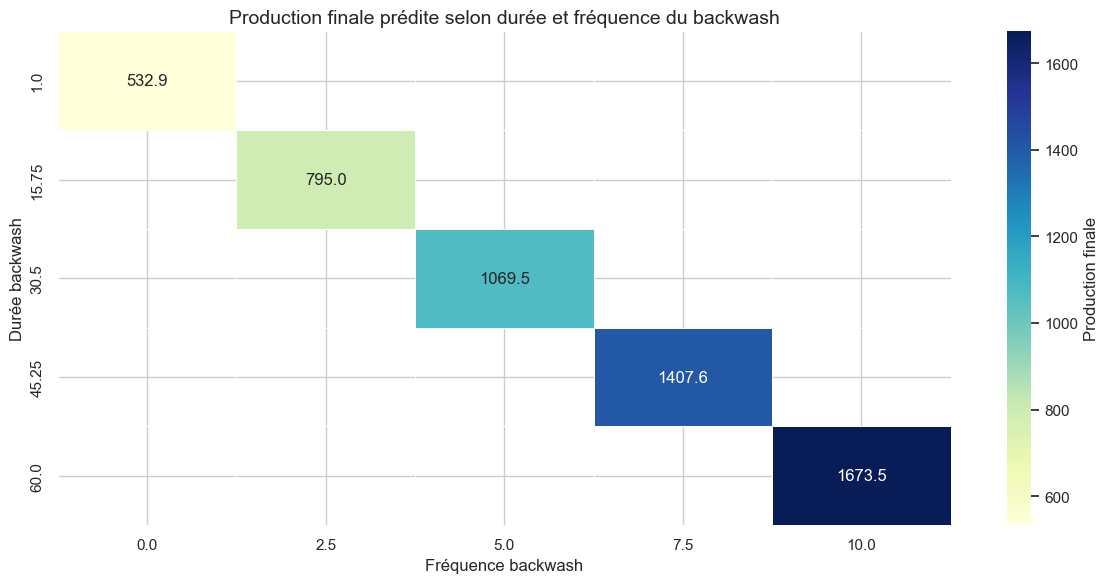

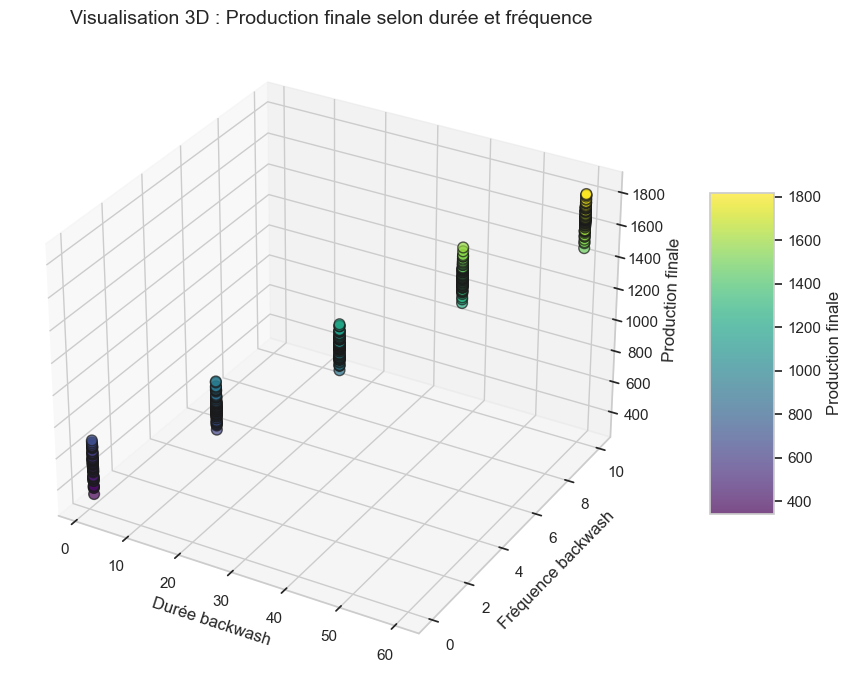

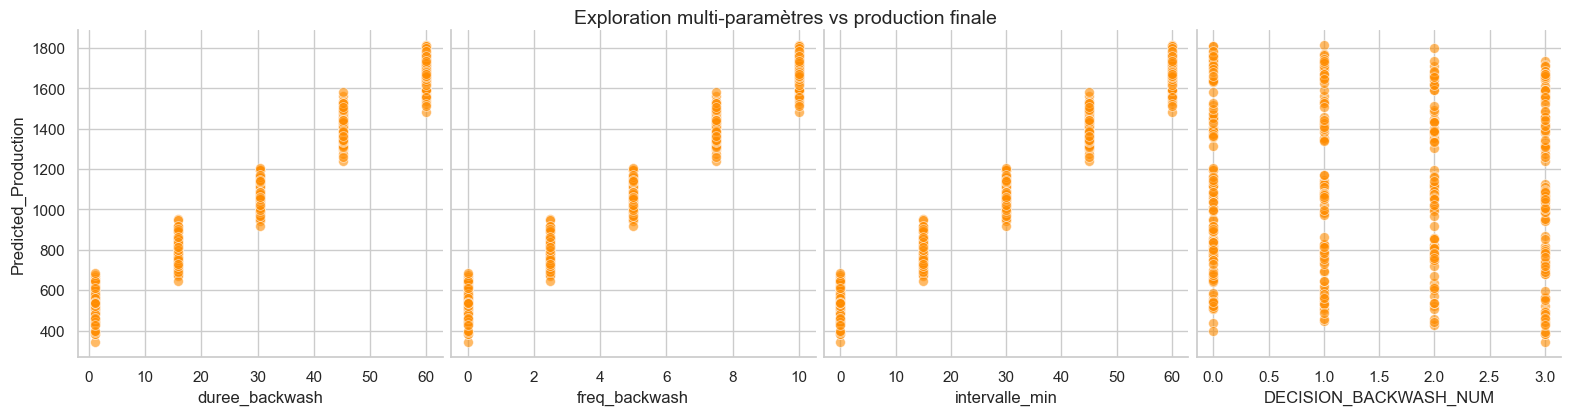

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
import numpy as np

# --- Style général ---
sns.set(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.autolayout': True})

# --- 0️⃣ Top N à afficher ---
top_n = 20  # nombre de meilleures combinaisons

# --- 1️⃣ Scatter : Production finale vs Décision Backwash ---
plt.figure(figsize=(12,6))
plt.scatter(results_df['DECISION_BACKWASH_NUM'], results_df['Predicted_Production'],
            alpha=0.6, c=results_df['Predicted_Production'], cmap='viridis')
plt.colorbar(label='Production finale prédite')
plt.xlabel('Décision Backwash (Code Numérique)')
plt.ylabel('Production finale prédite')
plt.title('Impact de la décision de backwash sur la production finale', fontsize=14)
plt.grid(True)
plt.show()

# --- 2️⃣ Pairplot simple pour explorer paramètres ---
sns.pairplot(
    results_df,
    x_vars=['duree_backwash','freq_backwash','intervalle_min'],
    y_vars='Predicted_Production',
    height=4,
    kind='scatter',
    plot_kws={'alpha':0.6, 's':50, 'color':'purple'}
)
plt.suptitle('Relations entre paramètres de backwash et production', y=1.02, fontsize=14)
plt.show()

# --- 3️⃣ Top N combinaisons selon production finale ---
top_df = results_df.sort_values('Predicted_Production', ascending=False).head(top_n)
print(f"Top {top_n} combinaisons selon production finale prédite :")
display(top_df[['DECISION_BACKWASH_NUM','duree_backwash','freq_backwash','intervalle_min','Predicted_Production']])

# --- 4️⃣ Heatmap : durée x fréquence du backwash ---
heat_df = results_df.pivot_table(
    values='Predicted_Production',
    index='duree_backwash',
    columns='freq_backwash',
    aggfunc='mean'
)

plt.figure(figsize=(12,6))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="YlGnBu", linewidths=.5, cbar_kws={'label':'Production finale'})
plt.title("Production finale prédite selon durée et fréquence du backwash", fontsize=14)
plt.xlabel("Fréquence backwash")
plt.ylabel("Durée backwash")
plt.show()

# --- 5️⃣ 3D Scatter Plot décoré ---
X = results_df['duree_backwash']
Y = results_df['freq_backwash']
Z = results_df['Predicted_Production']

fig = plt.figure(figsize=(12,7))
ax = fig.add_subplot(111, projection='3d')
p = ax.scatter(X, Y, Z, c=Z, cmap=cm.viridis, s=60, alpha=0.7, edgecolors='k')
fig.colorbar(p, ax=ax, shrink=0.5, aspect=5, label='Production finale')
ax.set_xlabel('Durée backwash')
ax.set_ylabel('Fréquence backwash')
ax.set_zlabel('Production finale')
plt.title('Visualisation 3D : Production finale selon durée et fréquence', fontsize=14)
plt.show()

# --- 6️⃣ Pairplot multi-paramètres décoré ---
sns.pairplot(
    results_df,
    x_vars=['duree_backwash','freq_backwash','intervalle_min','DECISION_BACKWASH_NUM'],
    y_vars='Predicted_Production',
    height=4,
    kind='scatter',
    plot_kws={'alpha':0.6, 's':50, 'color':'darkorange'}
)
plt.suptitle('Exploration multi-paramètres vs production finale', y=1.02, fontsize=14)
plt.show()
